## Neuron Networks
# I will be implementing a simple neuron.

In [29]:
!pip install nnfs

In [50]:
import math 
import random
import numpy as np
import nnfs
from typing import List, Union
from numpy import typing as npt
from matplotlib import pyplot as plt
nnfs.init()
from numpy.random import default_rng
from nnfs.datasets import spiral_data


def sigmoid(x):
    return 1 / (1 + math.exp(-x))

In [67]:
def neuron(inputs:list,weight:list,  bias:int, activation:str):
    
    # perform the dot product
    prods = []
    for a, b, in zip(inputs, weight):
        prods.append(a * b)
        
    # apply the activation function.
    if activation == "sigmoid":
        return sigmoid(sum(prods) + bias)
    

    print(output)

In [68]:
output = neuron(
    [1, 3.1, 0.5], 
    [2.36, 1.5, 0.3], 
    1.5, 
    "sigmoid"
)

output

0.9998266457500029

## Advancing from the neuron we can now implement a layer
### In many cases, when  implementing a neuron network e.g with the tensorflow framework the user does not need to specify the biases and the weights of their layers, in that light, I will be implemening a randomization of the weights and biases to micmic this

In [69]:
def layer(inputs:list, activation:str):

    outputs = []
    for n_inputs in inputs:
        weights = []
        for _ in range(len(n_inputs)):
            weights.append(random.normalvariate(1, 2))
        outputs.append(neuron(n_inputs, weights, random.randint(1, 205), activation))
    return outputs

In [72]:
inputs = [
    [2.05, 5.2, 5.3, 54],
    [5, 0.2, 0.3, 4],
    [1.5, 45, 58, 1],
    [45, 0.02, 2.5, 8],
    [14, 0.005,0.25, 4]
]


output = layer(inputs, "sigmoid")

output

[1.0, 1.0, 0.9999999193378207, 0.9999999999999913, 1.0]

From the above implementation, I have noticed a major draw back.
If the layers were to learn some give properties based on the input, a simple forward parsing would not do the tricks, to train the layer, we will have to implement back propagation, to archieve this, we will need to modify the previously generated or modified weights and biases for the layer to learn.
#### we over wrote the biases and weights

In [82]:
def làyér(inputs:list, activation:str):

    # generate the weights for the layer
    weights = []
    biases = []

    for _ in range(len(inputs)):
        biases.append(random.randint(5, 79))
    
    for _ in range(len(inputs[0])):
        l_weights = []
        for _ in range(len(inputs)):
            l_weights.append(random.normalvariate(0, 1))
        weights.append(l_weights)

    # perform the dot product
    output = []
    for i in range(len(inputs)):
        sum_prod = 0
        for j in range(len(inputs[0])):
            sum_prod += inputs[i][j] * weights[j][i]
        output.append(sigmoid(sum_prod + biases[i]))
    return output
            

In [84]:
inputs = [
    [2.05, 5.2, 5.3, 54],
    [5, 0.2, 0.3, 4],
    [1.5, 45, 58, 1],
    [45, 0.02, 2.5, 8],
    [14, 0.005,0.25, 4]
]

làyér(inputs, "sigmoid")

[1.0, 0.9999999999999742, 0.9762375018197205, 1.0, 1.0]

# Now our basic neuron layer has been implemented

# Moving forward let use work on a multilayered perceptron

From here one we can start using numpy to simplify the process of design the neuron network

`Lets design a 5 layer perceptron
Input layer with 5 input neurons
Hidden layers 
Output layer with 4 output neurons`

In [8]:
# Input neuron
# the input we will have an input batch of 3 by 4
inputs = np.linspace(1, 65, 12).reshape(3, 4)
inputs

array([[ 1.        ,  6.81818182, 12.63636364, 18.45454545],
       [24.27272727, 30.09090909, 35.90909091, 41.72727273],
       [47.54545455, 53.36363636, 59.18181818, 65.        ]])

In [11]:
# Moving to the first hidden layer

# The weights of this layer must be in a shape that is compatible with the input layers
# In this case 4 weight per neuron.So 4 by number of neurons say 7 and a bias array for each neuron's bias

first_layer_w = np.linspace(-12, 1, 28).reshape(7, 4)
first_layer_w

array([[-12.        , -11.51851852, -11.03703704, -10.55555556],
       [-10.07407407,  -9.59259259,  -9.11111111,  -8.62962963],
       [ -8.14814815,  -7.66666667,  -7.18518519,  -6.7037037 ],
       [ -6.22222222,  -5.74074074,  -5.25925926,  -4.77777778],
       [ -4.2962963 ,  -3.81481481,  -3.33333333,  -2.85185185],
       [ -2.37037037,  -1.88888889,  -1.40740741,  -0.92592593],
       [ -0.44444444,   0.03703704,   0.51851852,   1.        ]])

In [12]:
# Computation for the first layer

first_layer_output = np.dot(inputs, first_layer_w.T)
first_layer_output

array([[ -424.8013468 ,  -349.86531987,  -274.92929293,  -199.99326599,
         -125.05723906,   -50.12121212,    24.81481481],
       [-1474.65993266, -1220.43771044,  -966.21548822,  -711.99326599,
         -457.77104377,  -203.54882155,    50.67340067],
       [-2524.51851852, -2091.01010101, -1657.5016835 , -1223.99326599,
         -790.48484848,  -356.97643098,    76.53198653]])

### Note In python, when we generate a multi dimentional array in numpy it is in row vector form.
### What we want in a column vector, thus the transpose opperation.

For the second layer lets do 5 neurons and based on the output of the previous layer 7 weights neuron

In [20]:
second_layer_w = np.linspace(-11, 0.00245, 35).reshape(5, 7)
second_layer_w

array([[-1.10000000e+01, -1.06763985e+01, -1.03527971e+01,
        -1.00291956e+01, -9.70559412e+00, -9.38199265e+00,
        -9.05839118e+00],
       [-8.73478971e+00, -8.41118824e+00, -8.08758676e+00,
        -7.76398529e+00, -7.44038382e+00, -7.11678235e+00,
        -6.79318088e+00],
       [-6.46957941e+00, -6.14597794e+00, -5.82237647e+00,
        -5.49877500e+00, -5.17517353e+00, -4.85157206e+00,
        -4.52797059e+00],
       [-4.20436912e+00, -3.88076765e+00, -3.55716618e+00,
        -3.23356471e+00, -2.90996324e+00, -2.58636176e+00,
        -2.26276029e+00],
       [-1.93915882e+00, -1.61555735e+00, -1.29195588e+00,
        -9.68354412e-01, -6.44752941e-01, -3.21151471e-01,
         2.45000000e-03]])

In [24]:
third_layer_output = np.dot(first_layer_output, second_layer_w.T)
third_layer_output, third_layer_output.shape

(array([[14719.3845053 , 11548.19687112,  8377.00923695,  5205.82160277,
          2034.6339686 ],
        [52288.50523416, 40998.80390586, 29709.10257757, 18419.40124928,
          7129.69992098],
        [89857.62596301, 70449.4109406 , 51041.19591819, 31632.98089578,
         12224.76587337]]),
 (3, 5))

In [23]:
fourth_layer_w = np.linspace(7, 54, 15).reshape(3, 5)
fourth_layer_w, fourth_layer_w.shape

(array([[ 7.        , 10.35714286, 13.71428571, 17.07142857, 20.42857143],
        [23.78571429, 27.14285714, 30.5       , 33.85714286, 37.21428571],
        [40.57142857, 43.92857143, 47.28571429, 50.64285714, 54.        ]]),
 (3, 5))

In [25]:
fourth_layer_output = np.dot(third_layer_output, fourth_layer_w.T)
fourth_layer_output, fourth_layer_output.shape

(array([[  467962.19138626,  1171032.60948725,  1874103.02758824],
        [ 1658184.20358353,  4151626.74134385,  6645069.27910418],
        [ 2848406.2157808 ,  7132220.87320046, 11416035.53062013]]),
 (3, 3))

In [26]:
output_layer_w = np.linspace(879, 457, 3).reshape(1, 3)
output_layer_w

array([[879., 668., 457.]])

In [28]:
output = np.dot(fourth_layer_output, output_layer_w.T)
output

array([[2.05005363e+09],
       [7.26762724e+09],
       [1.24852008e+10]])

In [74]:
class Dense:
    def __init__(self, neurons:int, inputs:Union[List[float], npt.NDArray]  = None):
        self.inputs = np.array(inputs)
        self.neurons = neurons

class InputLayer:
    def __init__(self,inputs:Union[List[float], npt.NDArray]):
        self.inputs = np.array(inputs)

class LinearPerceptron:
    def __init__(self, layers):
        self.layers = layers
        self.rng = default_rng(seed=42)


    def forward(self):

        next_inputs = None
        for index, layer in enumerate(self.layers):
            
            if index == 0 and isinstance(layer, InputLayer):
                next_inputs = layer.inputs
                continue
                
            if next_inputs is None:
                next_inputs = layer.inputs

            # initialize the weights for the neurons at each layer
            weight_rows = next_inputs.shape[1]
            weight_columns = layer.neurons
            weights = self.rng.normal(loc=0, scale=1, size=(weight_rows, weight_columns))

            # Initialize the biases for the neurons at each layer
            bias = np.zeros((1, layer.neurons))

            next_inputs = np.dot(next_inputs, weights) + bias

        return next_inputs            

            

In [66]:
x, y = spiral_data(samples=1000, classes=5)

type(x)

numpy.ndarray

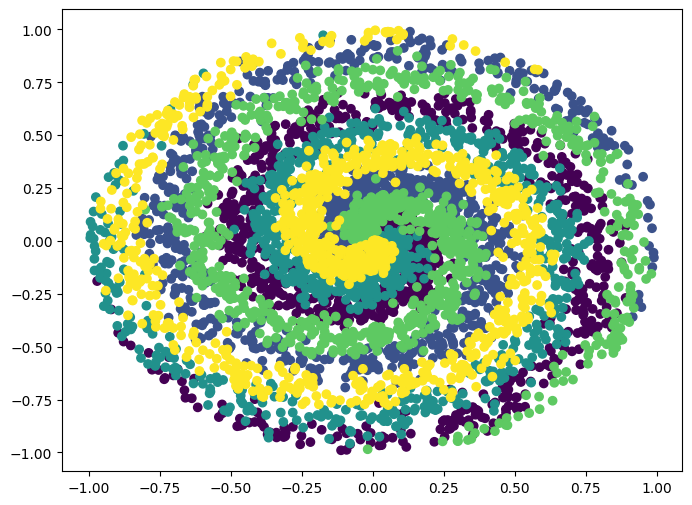

In [67]:
# Let plot out the data
plt.figure(figsize=(8, 6))
plt.scatter(x[:, 0], x[:, 1], c=y, cmap="viridis")

In [75]:
# feed the data to out neuron network
perceptron = LinearPerceptron(
    [
        InputLayer(x),
        Dense(8),
        Dense(16),
        Dense(32),
        Dense(128),
        Dense(96),
        Dense(36),
        Dense(18),
        Dense(9),
        Dense(3),
        Dense(1)
    ]
)


perceptron.forward()

array([[ 0.0000000e+00],
       [ 3.3070938e+02],
       [-7.8657036e+01],
       ...,
       [ 2.2545159e+05],
       [ 3.4725691e+05],
       [ 3.2443259e+05]], shape=(5000, 1), dtype=float32)

In [78]:
perceptron = LinearPerceptron(
    [
        Dense(4, x),
        Dense(8),
        Dense(16),
        Dense(32),
        Dense(128),
        Dense(96),
        Dense(36),
        Dense(18),
        Dense(9),
        Dense(3),
        Dense(1)
    ]
)

perceptron.forward()

array([[0.0000000e+00],
       [2.1805000e+02],
       [5.0513959e+02],
       ...,
       [2.8646356e+05],
       [1.8308934e+05],
       [2.2603825e+05]], shape=(5000, 1), dtype=float32)